# IMPORTS DUH

In [3]:
from pyod.utils.data import generate_data
from matplotlib import pyplot as plt
from pyod.models.knn import KNN
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_curve
import numpy as np

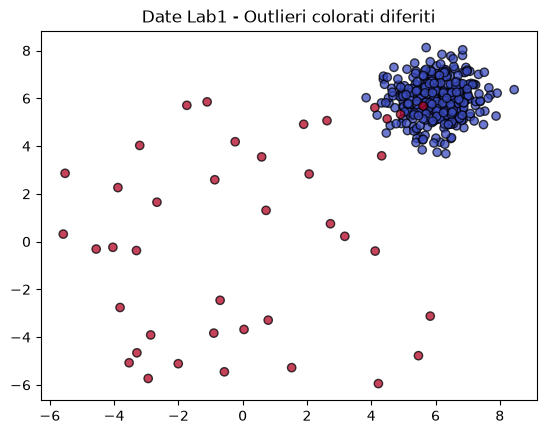

In [ ]:
# EX 1 - generate data and plot them

values = generate_data(n_train=400, n_test=100, n_features=2, contamination=0.1)
X_train = values[0]
Y_train = values[2]

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=Y_train,
    cmap="coolwarm",
    edgecolor="k",
    alpha=0.75,
)
plt.title("Date Lab1 - Outlieri colorati diferiti")
plt.show()

Train Performance:
TN: 359, FP: 1, FN: 1, TP: 39
Balanced Accuracy: 0.9861

Test Performance:
TN: 89, FP: 1, FN: 0, TP: 10
Balanced Accuracy: 0.9944



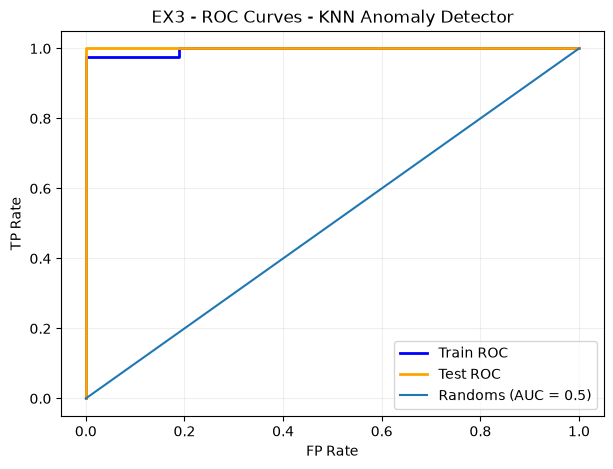

Testing with different contamination rates:
Contamination Rate: 0.05
TN: 90, FP: 0, FN: 4, TP: 6
Balanced Accuracy: 0.8000

Contamination Rate: 0.1
TN: 89, FP: 1, FN: 0, TP: 10
Balanced Accuracy: 0.9944

Contamination Rate: 0.15
TN: 78, FP: 12, FN: 0, TP: 10
Balanced Accuracy: 0.9333

Contamination Rate: 0.2
TN: 75, FP: 15, FN: 0, TP: 10
Balanced Accuracy: 0.9167



In [ ]:
# EX 2

contamination = 0.1

# generate data - again bcs why not
X_train, X_test, Y_train, Y_test = generate_data(
    n_train = 400,
    n_test = 100,
    n_features = 2,
    contamination = contamination,
)

# initialize knn with matching contamination rate to the data generation
clf = KNN(contamination=contamination)

# fit on the training data
clf.fit(X_train)

# predictions for the training data
y_train_pred = clf.predict(X_train)
y_train_scores = clf.decision_function(X_train)

# predictions for the testing data
y_test_pred = clf.predict(X_test)
y_test_scores = clf.decision_function(X_test)

# function made to find the number of tn, tp, fn, fp and the balanced accuracy
def evaluate_performance(y_true, y_pred, split_name="Test"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"{split_name} Performance:")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Balanced Accuracy: {bal_acc:.4f}\n")

evaluate_performance(Y_train, y_train_pred, split_name="Train")
evaluate_performance(Y_test, y_test_pred, split_name="Test")

# compute ROC curves using continuous decision scores
fpr_train, tpr_train, _ = roc_curve(Y_train, y_train_scores)
fpr_test, tpr_test, _ = roc_curve(Y_test, y_test_scores)

# plot them curveeeez

plt.figure(figsize=(7, 5))
plt.plot(fpr_train, tpr_train, label="Train ROC", color="blue", lw=2)
plt.plot(fpr_test, tpr_test, label="Test ROC", color="orange", lw=2)
plt.plot([0, 1], [0, 1], label="Randoms (AUC = 0.5)")

plt.title("EX3 - ROC Curves - KNN Anomaly Detector")
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

# testing them with different contamination rates !!!!!!!!
print("Testing with different contamination rates:")

test_rates = [0.05, 0.1, 0.15, 0.2]

for rate in test_rates:
    temp_clf = KNN(contamination=rate)
    temp_clf.fit(X_train)

    preds = temp_clf.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(Y_test, preds).ravel()
    bal_acc = balanced_accuracy_score(Y_test, preds)

    print(f"Contamination Rate: {rate}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Balanced Accuracy: {bal_acc:.4f}\n")
    

In [5]:
# EX 3

contamination = 0.1

# generam setul de date cu o singura caracteristica / o singura dimensiune (ca albumele lu Taylor Swift)
X_train, _, Y_train, _ = generate_data(n_train=1000, n_features=1, contamination=contamination)


# aplatizam X train la un vector 1D
X = X_train.ravel()

# calculam Z-scores 

mean = np.mean(X) # media
std = np.std(X) #deviatia standard

# acum chiar calculam Z-scores
z_scores = (X - mean) / std

# aici facem ca valorile extreme echidistante sa fie la fel de anomalitice
abs_z_scores = np.abs(z_scores)

# vrem ca threshold ul sa fie egal cu contamination ul
threshold = np.percentile(abs_z_scores, (1 - contamination) * 100)
print(f"Pragul smecheriei de Z-score este {threshold:.4f}")

# clasificam acum punctele 

y_pred = (abs_z_scores > threshold).astype(int)

# evaluam cat de performant este modelul nostru (un fel de valentino rossi al detectiei de anomalii)
tn, fp, fn, tp = confusion_matrix(Y_train, y_pred).ravel()
bal_acc = balanced_accuracy_score(Y_train, y_pred)

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"Balanced Accuracy: {bal_acc:.4f}\n")


Pragul smecheriei de Z-score este 0.7113
TN: 879, FP: 21, FN: 21, TP: 79
Balanced Accuracy: 0.8833



Pragul pentru Z-scores multidimensionali este 2.7343
TN: 884, FP: 16, FN: 16, TP: 84
Balanced Accuracy: 0.9111



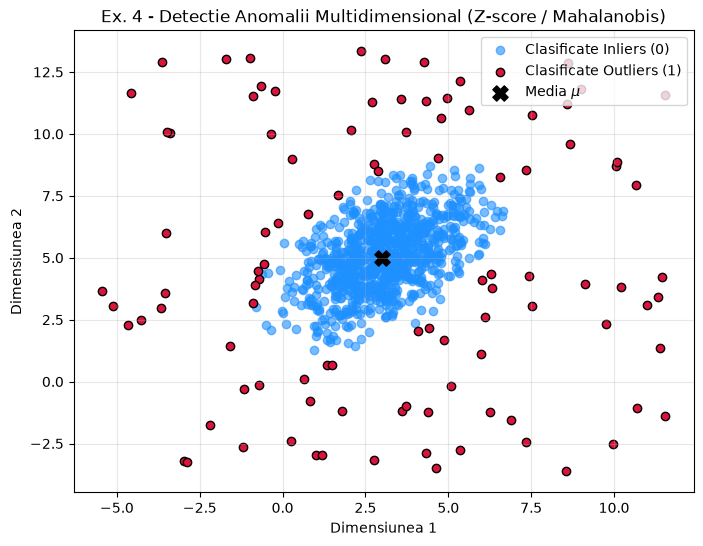

In [8]:
# EX 4 

np.random.seed(42)  # pentru reproductibilitate

n_samples = 1000
contamination = 0.1
n_outliers = int(n_samples * contamination)
n_inliers = n_samples - n_outliers

# vectorul medie mu ales arbitrar
mu = np.array([3.0, 5.0])

# folosim matricea de covarianta Sigma (simetrica si pozitiv definita cum a zis domnul Rusu la curs)

Sigma = np.array([[2.0, 1.0], [1.0, 2.0]])

# descompunerea Cholesky si generarea inliers ilor

# Avem formula Sigma = L * L^T
L = np.linalg.cholesky(Sigma)

x_standard = np.random.randn(n_inliers, 2)

# din acea formula putem scoate y = L* x + mu
# pt o matrice de forma (N,2) avem
# y = (L * X^T)^T + mu = x * L^T + mu

y_inliers = x_standard @ L.T + mu

# generam anomaliile 

# pct care nu respecta densitatea normala

low_bound = mu - 4 * np.sqrt(np.diag(Sigma))
high_bound = mu + 4 * np.sqrt(np.diag(Sigma))

y_outliers = np.random.uniform(low=low_bound - 3, high= high_bound + 3, size=(n_outliers, 2))

# combinam inliers si outliers

x = np.vstack((y_inliers, y_outliers))

y_true = np.hstack([np.zeros(n_inliers, dtype=int), np.ones(n_outliers, dtype=int)])

# calculam z-scores miltidimensionale - distanta mahalanobis

# z_i = sqrt((x_i - mu)^T * Sigma^-1 * (x_i - mu))

inv_Sigma = np.linalg.inv(Sigma)

diff = x - mu
mahalanobis_sq = np.sum(diff @ inv_Sigma * diff, axis=1)


z_scores = np.sqrt(mahalanobis_sq)

# calculam pragul cu np,quantile()

threshold = np.percentile(z_scores, (1 - contamination) * 100)

print(f"Pragul pentru Z-scores multidimensionali este {threshold:.4f}")

y_pred = (z_scores > threshold).astype(int)

# evaluam performanta - pentru ultima oara la aceasta tema

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"Balanced Accuracy: {bal_acc:.4f}\n")

# haideti sa si vizualizam datele ca am capu greu si inteleg mai greu aiae
plt.figure(figsize=(8, 6))
plt.scatter(x[y_pred == 0, 0], x[y_pred == 0, 1], c='dodgerblue', alpha=0.6, label='Clasificate Inliers (0)')
plt.scatter(x[y_pred == 1, 0], x[y_pred == 1, 1], c='crimson', edgecolors='k', label='Clasificate Outliers (1)')
plt.scatter(mu[0], mu[1], c='black', marker='X', s=120, label=r'Media $\mu$')
plt.title("Ex. 4 - Detectie Anomalii Multidimensional (Z-score / Mahalanobis)")
plt.xlabel("Dimensiunea 1")
plt.ylabel("Dimensiunea 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
